**The notebook presents classification problem of EV Charger User Type **

1. Classification of User Type
  * Commuter
  * Causal Driver
  * Long-Distance Traveler
2. Charging cost prediction

In [222]:
import os.path

import kagglehub
import pandas as pd
from matplotlib import pyplot as plt

# Display all rows and all columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Load data from Kagglehub

In [223]:
# Download dataset from Kaggle
dataset_name = 'valakhorasani/electric-vehicle-charging-patterns'
path = kagglehub.dataset_download(dataset_name)

# Set full path to the file
filename = 'ev_charging_patterns.csv'
filepath = os.path.join(path, filename)

In [224]:
# Load dataset
df = pd.read_csv(filepath)

print('--- Dataframe shape ---')
print(df.shape, '\n')

print('--- Dataframe info ---')
df.info()

print('\n')
print('---Dataframe first 5 rows ---')
print(df.head(), '\n')

print('--- Dataframe types ---')
print(df.dtypes, '\n')

print('--- Dataframe NaN columns ---')
print(df.isnull().sum(), '\n')

print('--- Dataframe duplicated rows ---')
print('Duplicated rows in total: {}\n'.format(df.duplicated().sum()))

print('--- Dataframe distinct column count ---')
distinct_values = pd.DataFrame(df.nunique(), columns=['Distinct Count'])
print(distinct_values)

--- Dataframe shape ---
(1320, 20) 

--- Dataframe info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User ID                                   1320 non-null   object 
 1   Vehicle Model                             1320 non-null   object 
 2   Battery Capacity (kWh)                    1320 non-null   float64
 3   Charging Station ID                       1320 non-null   object 
 4   Charging Station Location                 1320 non-null   object 
 5   Charging Start Time                       1320 non-null   object 
 6   Charging End Time                         1320 non-null   object 
 7   Energy Consumed (kWh)                     1254 non-null   float64
 8   Charging Duration (hours)                 1320 non-null   float64
 9   Charging Rate (kW)                        1254 

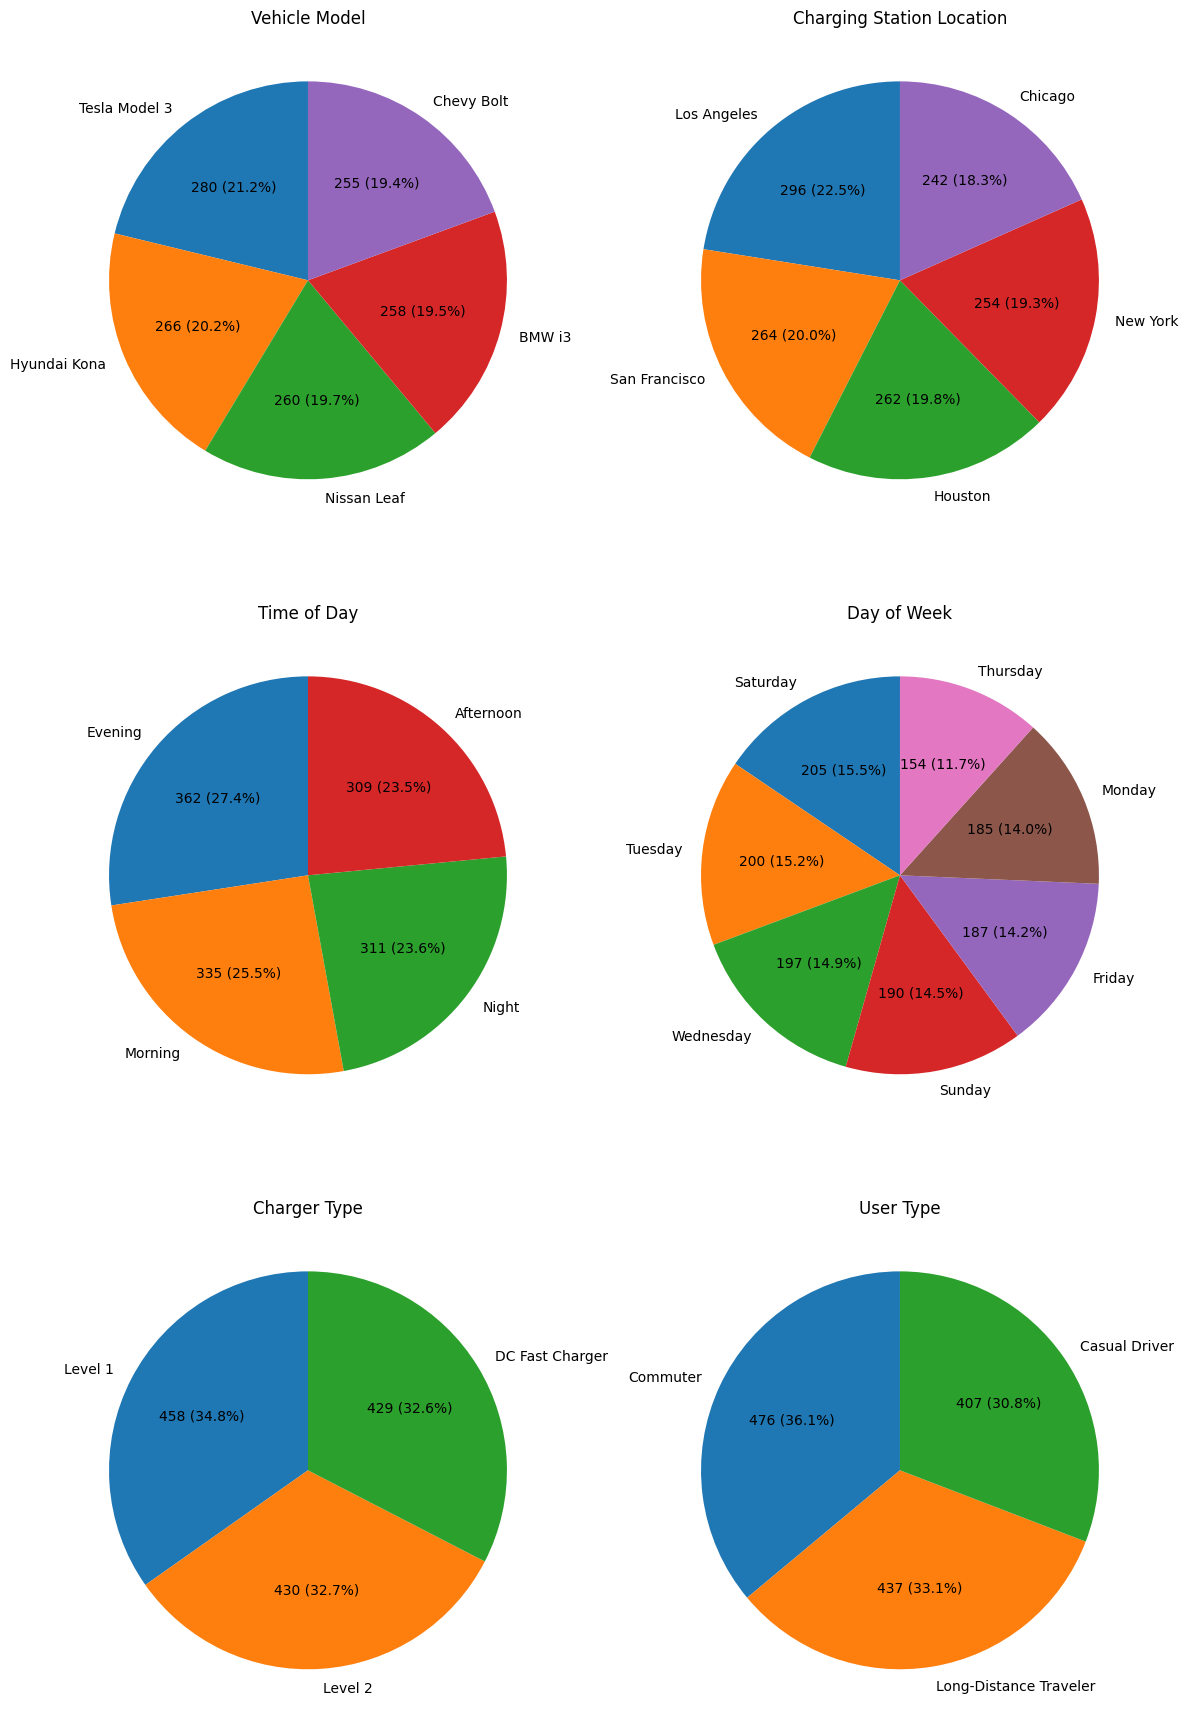

In [225]:
import matplotlib.pyplot as plt

def create_pie_chart(axis, data, title):
    axis.pie(data, labels=data.index, autopct=lambda pct: pie_chart_value(pct, data), startangle=90)
    axis.set_title(title)

def pie_chart_value(pct, total):
    absolute = int(pct / 100 * sum(total))
    return f'{absolute} ({pct:.1f}%)'

# Define display columns
display_columns = [ 'Vehicle Model', 'Charging Station Location', 'Time of Day', 'Day of Week', 'Charger Type', 'User Type']

fig, axes = plt.subplots(3, 2, figsize=(12, 18))

for i, col in enumerate(display_columns):
    row, col_idx = divmod(i, 2)  # Get row and column index
    data = df[col].value_counts()  # Get the count of distinct values for the column
    create_pie_chart(axes[row, col_idx], data, col)  # Use column name as title

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [226]:
# Fill NaN values with mean value
for column in df.select_dtypes(include='float').columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mean())

# Convert columns to datetime
df['Charging End Time'] = pd.to_datetime(df['Charging End Time'])
df['Charging Start Time'] = pd.to_datetime(df['Charging Start Time'])

index = df.columns.get_loc('Charging End Time') + 1

# Use one column instead of two, convert to hours
charger_connection_time = (df['Charging End Time'] - df['Charging Start Time']).dt.total_seconds() / 3600
df.insert(index, 'Charger Connection Duration (hours)', charger_connection_time)

# Drop redundant columns
df = df.drop(['User ID', 'Charging Station ID', 'Charging Station Location', 'Charging Start Time', 'Charging End Time'], axis=1)

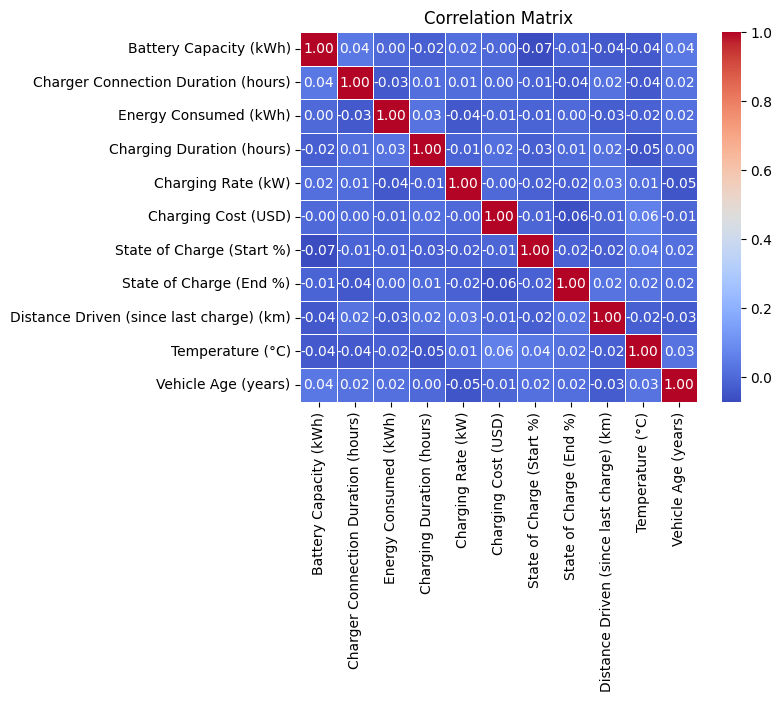

In [227]:
import seaborn as sns

# Find numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

fig.show()
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [228]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

numeric_columns = numeric_df.columns

# Initialize MinMaxScalers
minmax_scalers = {}

for column in numeric_columns:
    minmax_scaler = MinMaxScaler()
    minmax_scalers[column] = minmax_scaler
    df[column] = minmax_scaler.fit_transform(df[[column]])

# Use label encoding for nominal values
le_user_type = LabelEncoder()
df['User Type Encoded'] = le_user_type.fit_transform(df['User Type'])

# Use One Hot Encoding for selected columns
df = pd.get_dummies(df, columns=['Vehicle Model', 'Time of Day', 'Day of Week', 'Charger Type', 'User Type'], dtype=int)

print('--- Dataframe info ---')
df.info()

print('--- Dataframe head ---')
print(df.head())

print('--- Dataframe describe ---')
print(df.describe())

--- Dataframe info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 34 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Battery Capacity (kWh)                    1320 non-null   float64
 1   Charger Connection Duration (hours)       1320 non-null   float64
 2   Energy Consumed (kWh)                     1320 non-null   float64
 3   Charging Duration (hours)                 1320 non-null   float64
 4   Charging Rate (kW)                        1320 non-null   float64
 5   Charging Cost (USD)                       1320 non-null   float64
 6   State of Charge (Start %)                 1320 non-null   float64
 7   State of Charge (End %)                   1320 non-null   float64
 8   Distance Driven (since last charge) (km)  1320 non-null   float64
 9   Temperature (°C)                          1320 non-null   float64
 10  Vehicle Age (

In [229]:
from sklearn.model_selection import train_test_split

# Split to X and y sets
X = df[df.columns.drop(df.filter(regex='^User Type').columns)]
y = df['User Type Encoded']

# Split data in to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

print('--- Dataframe X shape ---')
print(X.shape , '\n')
print('--- Dataframe y shape ---')
print(y.shape , '\n')

print('--- Dataframe X_train shape ---')
print(X_train.shape , '\n')
print('--- Dataframe y_train shape ---')
print(y_train.shape , '\n')

print('--- Dataframe X_test shape ---')
print(X_test.shape , '\n')
print('--- Dataframe y_test shape ---')
print(y_test.shape)

--- Dataframe X shape ---
(1320, 30) 

--- Dataframe y shape ---
(1320,) 

--- Dataframe X_train shape ---
(1056, 30) 

--- Dataframe y_train shape ---
(1056,) 

--- Dataframe X_test shape ---
(264, 30) 

--- Dataframe y_test shape ---
(264,)


In [230]:
#!pip install xgboost

import xgboost as xgb

# Define XGBClassifier model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

# and make predictions
y_prob = xgb_model.predict_proba(X_test)
y_pred = xgb_model.predict(X_test)

In [231]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Show classification report
print('--- Classification report ---')
print(classification_report(y_test, y_pred))

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)
print('--- Model accuracy ---')
print('Accuracy: %.2f%%' % (accuracy * 100.0))

--- Classification report ---
              precision    recall  f1-score   support

           0       0.34      0.29      0.32        78
           1       0.41      0.35      0.38       112
           2       0.29      0.39      0.33        74

    accuracy                           0.34       264
   macro avg       0.35      0.34      0.34       264
weighted avg       0.35      0.34      0.35       264

--- Model accuracy ---
Accuracy: 34.47%


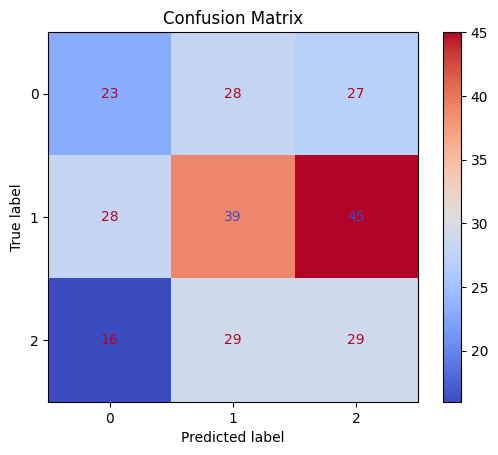

In [232]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# Show confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
model_classes = xgb_model.classes_
classnames = le_user_type.inverse_transform(model_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model_classes)
disp.plot(cmap='coolwarm')
plt.title('Confusion Matrix')
plt.show()

                      Feature  Importance
24       Day of Week_Thursday    0.049910
21         Day of Week_Monday    0.041938
14  Vehicle Model_Nissan Leaf    0.041171
22       Day of Week_Saturday    0.041162
12   Vehicle Model_Chevy Bolt    0.038918
29       Charger Type_Level 2    0.037843
23         Day of Week_Sunday    0.036575
20         Day of Week_Friday    0.035660
26      Day of Week_Wednesday    0.035258
4          Charging Rate (kW)    0.034770


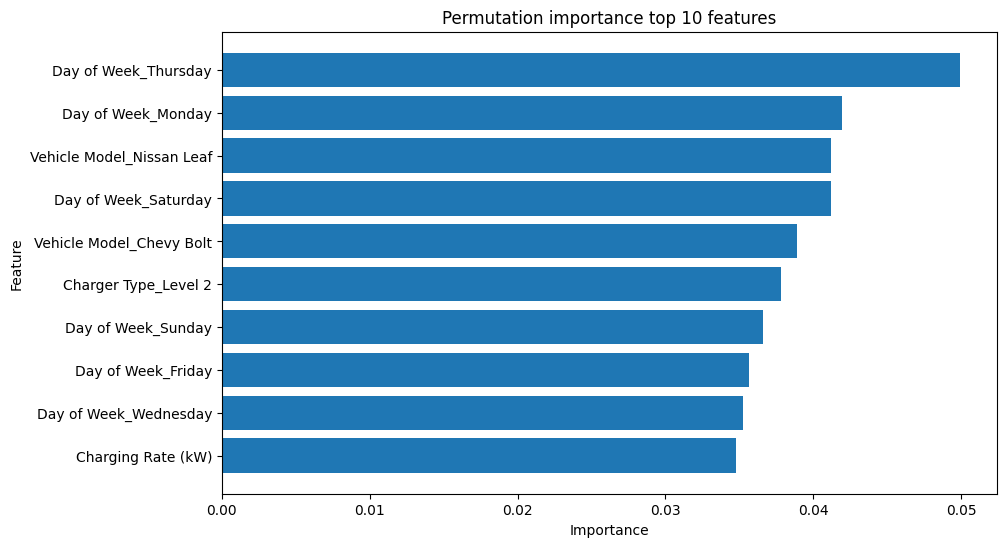

In [233]:
from sklearn.inspection import permutation_importance

feature_names = X_train.columns
feature_importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

# Top 10 Features
top_10_features = importance_df.head(10)
print(top_10_features)

# Optional: Visualize
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"])
plt.title("Permutation importance top 10 features")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

 91%|==================  | 723/792 [00:12<00:01]       

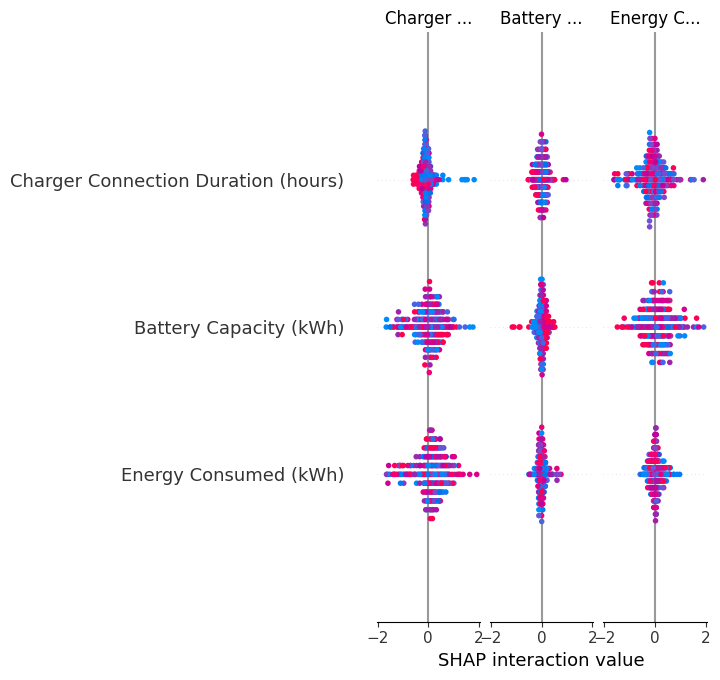

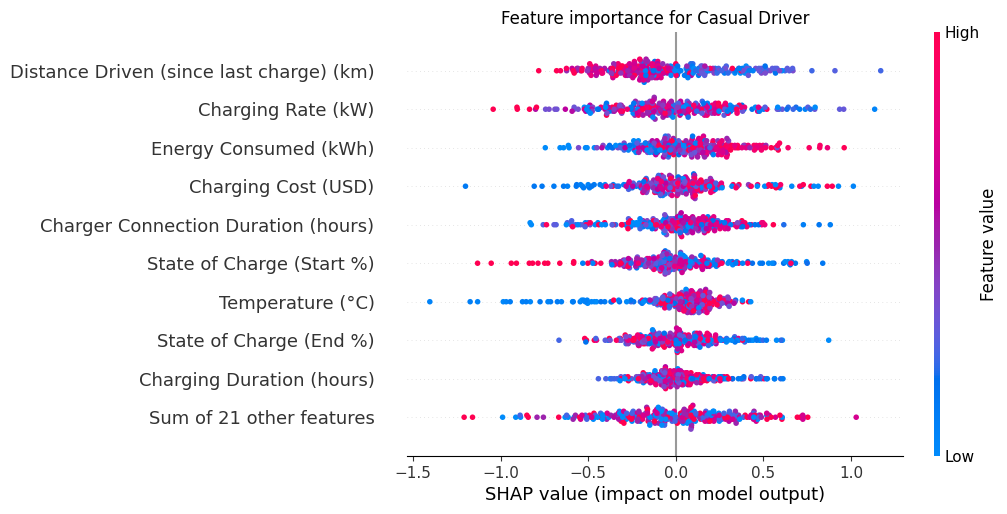

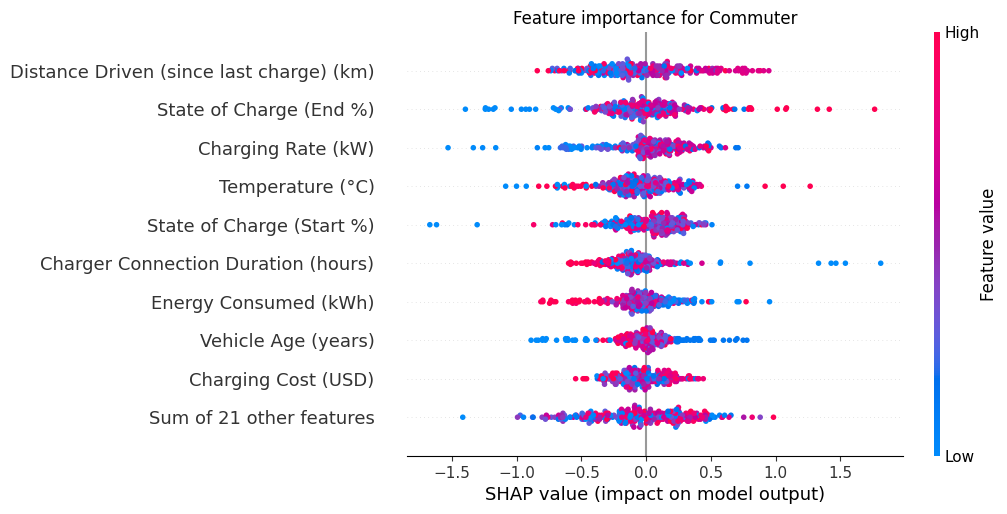

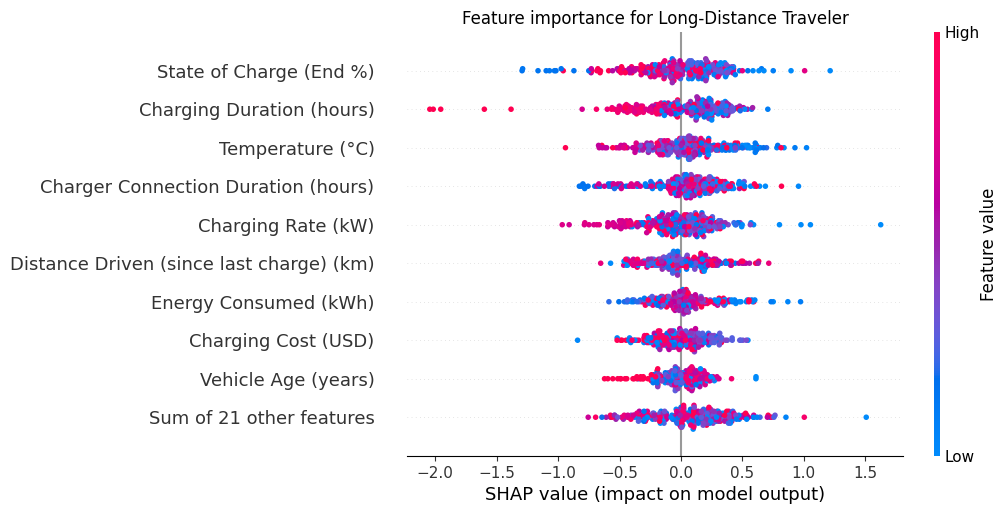

In [234]:
#!pip install shap

import shap

# Calculate Shapley values for given test set
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Display Shap summary plot
shap.summary_plot(shap_values, X_test, feature_names = X_train.columns)

# Display Shap feature importance for each class
for i in range(3):
    plt.title(f'Feature importance for {classnames[i]}')
    shap.plots.beeswarm(shap_values[:, :, i])
    plt.show()

Accuracy: 32.95%


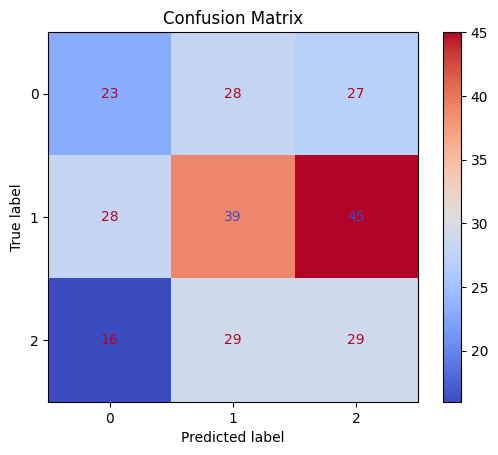

In [235]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale X_train and X_test
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_ts_scaled = scaler.transform(X_test)

# Check LogisticRegression for comparison
lr_model = LogisticRegression(max_iter=100)
lr_model.fit(X_tr_scaled, y_train)

y_pred = xgb_model.predict(X_ts_scaled)

# Check accuracy
accuracy = lr_model.score(X_ts_scaled, y_test)
print('Accuracy: %.2f%%' % (accuracy * 100.0))

# Show confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model_classes)
disp.plot(cmap='coolwarm')
plt.title('Confusion Matrix')
plt.show()

In [236]:
# Redefine X and y for regression problem
scaler = minmax_scalers['Charging Cost (USD)']

X = df.drop(labels=['Charging Cost (USD)', 'User Type Encoded'], axis='columns')
y = scaler.inverse_transform(df['Charging Cost (USD)'].values.reshape(-1, 1))

# Split data in to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Define XGBRegressor model
xgb_reg_model = xgb.XGBRegressor()
xgb_reg_model.fit(X_train, y_train)

y_pred = xgb_reg_model.predict(X_test)


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")


Mean Absolute Error (MAE): 10.118037103246627
Mean Squared Error (MSE): 149.48746052255245
Root Mean Squared Error (RMSE): 12.22650647251914
R-squared (R²): -0.21448721054564635


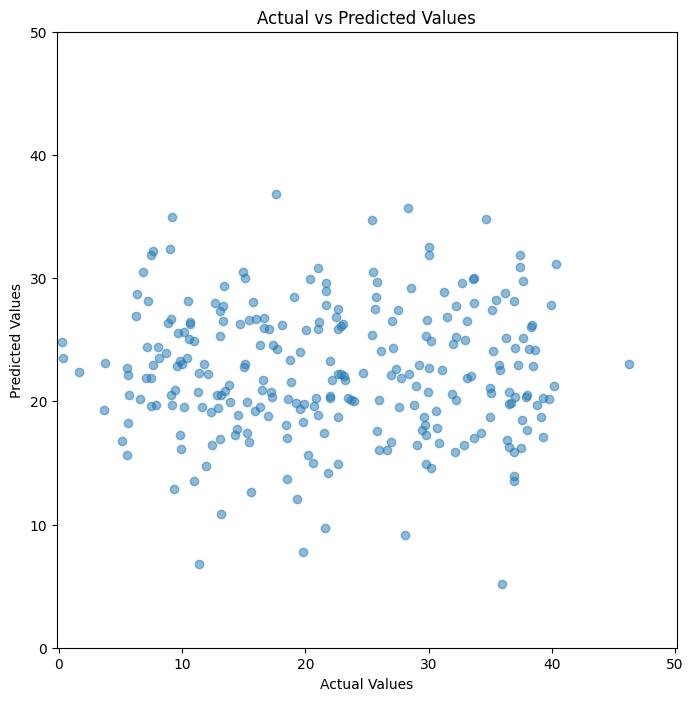

In [237]:
# Present actual and predicted values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.axis("equal")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.xlim(0, 50)
plt.ylim(0, 50)
plt.title("Actual vs Predicted Values")
plt.show()

In [238]:
# Define objective func for xgb.XGBClassifier model

def objective(trial):
    # Suggest hyperparameters for XGBRegressor
    param = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 6, 20),
        'max_leaves': trial.suggest_int('max_depth', 1, 20)
    }

    # Create XGBRegressor model with suggested hyperparameters
    best_model = xgb.XGBRegressor(**param)

    # Train the model
    best_model.fit(X_train, y_train)

    # Make predictions
    y_pred = best_model.predict(X_test)

    return mean_squared_error(y_test, y_pred)

In [239]:
#!pip install optuna
#!pip install ploty

import optuna
import plotly

# Create an Optuna study so we want to minimize RMSE
# study = optuna.create_study(direction='minimize')

# Optimize the objective function
study.optimize(objective, n_trials=100)
best_params = study.best_params

# Print the best hyperparameters found by Optuna
print("Best hyperparameters: ", best_params)

# Train the final model with the best hyperparameters
best_model = xgb.XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)

# Calculate the performance of the best model
final_rmse = mean_squared_error(y_test, y_pred_best)
print("Final RMSE with best hyperparameters: ", final_rmse)

optuna.visualization.plot_optimization_history(study)

/usr/local/lib/python3.10/dist-packages/optuna/trial/_trial.py:678: RuntimeWarning:

Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 6, 'high': 20}

[I 2024-12-07 13:18:17,599] Trial 120 finished with value: 123.08922848532623 and parameters: {'learning_rate': 1.2643334672726919e-05, 'max_depth': 7}. Best is trial 101 with value: 123.08877581525937.
/usr/local/lib/python3.10/dist-packages/optuna/trial/_trial.py:678: RuntimeWarning:

Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent o

Best hyperparameters:  {'learning_rate': 1.019254860983928e-05, 'max_depth': 7}
Final RMSE with best hyperparameters:  123.09189548694054


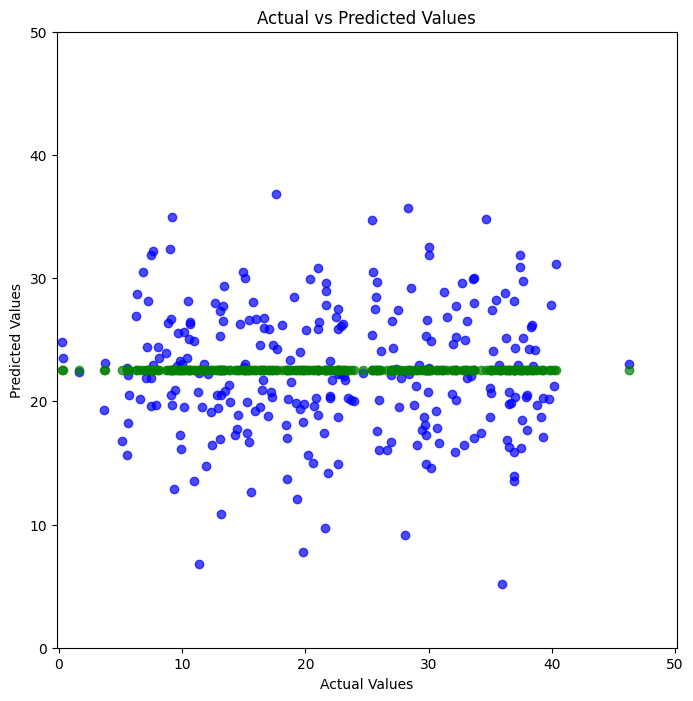

In [240]:
# Present actual values for normal and optimized model
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, color='blue', label='Predicted', alpha=0.7)
plt.scatter(y_test, y_pred_best, color='green', label='Predicted (hyperparams optimization)', alpha=0.7)
plt.axis("equal")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.xlim(0, 50)
plt.ylim(0, 50)
plt.title("Actual vs Predicted Values")
plt.show()